In [1]:
!pip install --upgrade imbalanced-learn
!pip install --upgrade scikit-learn
!pip install opencv-python-headless 
!pip install torch torchvision pandas numpy matplotlib seaborn opencv-python scikit-learn Pillow imblearn tqdm
!pip install pandas lime scikit-image -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 21.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
!pip install thop -q

In [12]:
import os, time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import mark_boundaries, find_boundaries
import torch.nn.functional as F
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from lime import lime_image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# --- CONFIGURATION ---
MODEL1_PATH = '/kaggle/input/datasets/deblinamazumdersetu/ourensemble1/model1/best_segmentation_model1.pth'
MODEL2_PATH = '/kaggle/input/datasets/deblinamazumdersetu/ourensemble1/model1/best_transunetpp_model.pth'
MODEL3_PATH = '/kaggle/input/datasets/deblinamazumdersetu/model3d/best_segmentation_model3.pth'
METADATA_PATH = '/kaggle/input/datasets/deblinamazumdersetu/t2metadata/T2_age_gender_evaluation.csv'
TEST_DIR = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/test'
TRAIN_DIR = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/train'
VAL_DIR = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/valid'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- METRICS ---
def calculate_metrics(preds, targets, smooth=1e-6):
    preds_sig = torch.sigmoid(preds)
    preds_bin = (preds_sig > 0.5).float()
    preds_flat, targets_flat = preds_bin.view(-1), targets.view(-1)
    intersection = (preds_flat * targets_flat).sum()
    total = preds_flat.sum() + targets_flat.sum()
    union = total - intersection
    dice = (2. * intersection + smooth) / (total + smooth)
    iou = (intersection + smooth) / (union + smooth)
    return dice.item(), iou.item()

# --- DATAFRAME CREATION ---
metadata_df = pd.read_csv(METADATA_PATH)
metadata_df.rename(columns={'Patient ID': 'ID', 'Radiological Evaluation': 'radiological_evaluation'}, inplace=True)
metadata_df.dropna(subset=['radiological_evaluation'], inplace=True)
metadata_df['radiological_evaluation'] = metadata_df['radiological_evaluation'].astype(int)
metadata_df['ID'] = metadata_df['ID'].astype(str)
class_name_map = {1: 'Mild', 2: 'Moderate', 3: 'Severe'}
metadata_df['class_name'] = metadata_df['radiological_evaluation'].map(class_name_map)
valid_ids = set(metadata_df['ID'].tolist())

def create_dataframe_from_ids(directory, allowed_ids):
    data = []
    if not os.path.exists(directory): return pd.DataFrame(data)
    for folder_name in os.listdir(directory):
        if folder_name in allowed_ids:
            folder_path = os.path.join(directory, folder_name)
            images_dir, masks_dir = os.path.join(folder_path, 'images'), os.path.join(folder_path, 'masks')
            if os.path.exists(images_dir) and os.path.exists(masks_dir):
                for image_file in os.listdir(images_dir):
                    image_path = os.path.join(images_dir, image_file)
                    mask_path = os.path.join(masks_dir, image_file)
                    if os.path.exists(mask_path): data.append((folder_name, image_path, mask_path))
    return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])

test_df = create_dataframe_from_ids(TEST_DIR, valid_ids)
test_df = pd.merge(test_df, metadata_df[['ID', 'class_name']], on='ID')

# --- TRANSFORMS & DATASET ---
class SegmentationTransform:
    def __init__(self, image_size=(224, 224)):
        self.image_size = image_size
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    def __call__(self, image, mask):
        image = image.resize(self.image_size, Image.BILINEAR)
        mask = mask.resize(self.image_size, Image.NEAREST)
        image_tensor = transforms.ToTensor()(image)
        mask_tensor = transforms.ToTensor()(mask)
        return self.normalize(image_tensor), (mask_tensor > 0).float()

class LiverDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_pil = Image.open(row['image_file_path']).convert('RGB')
        mask_pil = Image.open(row['mask_file_path']).convert('L')
        image, mask = self.transform(image_pil, mask_pil)
        return image, mask, row['image_file_path'], row['class_name']

# --- MODEL ARCHITECTURES (same as your code) ---
# ConvBlock, DecoderBlock, UNetWithResNet50Encoder, TransUNetPP, AttentionGate, AttentionUNet
# [Keep your definitions unchanged here]

# --- LOADING MODELS ---
model1 = UNetWithResNet50Encoder(n_classes=1).to(device)
model1.load_state_dict(torch.load(MODEL1_PATH, map_location=device)); model1.eval()
model2 = TransUNetPP(n_classes=1).to(device)
model2.load_state_dict(torch.load(MODEL2_PATH, map_location=device)); model2.eval()
model3 = AttentionUNet(n_classes=1).to(device)
model3.load_state_dict(torch.load(MODEL3_PATH, map_location=device)); model3.eval()

# --- COMPUTATIONAL COMPLEXITY & INFERENCE TIME ---
from thop import profile
def analyze_model(model, name):
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)
    start = time.time()
    with torch.no_grad():
        for _ in range(50): model(dummy_input)
    end = time.time()
    avg_time = (end - start)/50
    print(f"\n{name} Analysis:")
    print(f"Parameters: {params/1e6:.2f}M")
    print(f"FLOPs: {flops/1e9:.2f} GFLOPs")
    print(f"Avg Inference Time (224x224): {avg_time*1000:.2f} ms")

analyze_model(model1, "UNet-ResNet50")
analyze_model(model2, "TransUNetPP")
analyze_model(model3, "AttentionUNet")

# --- REST OF YOUR PIPELINE ---
# Segmentation predictions, ensembling, visualization, classification stage
# [Keep your original code unchanged from here onwards]


Using device: cuda

UNet-ResNet50 Analysis:
Parameters: 43.86M
FLOPs: 13.86 GFLOPs
Avg Inference Time (224x224): 11.55 ms

TransUNetPP Analysis:
Parameters: 138.82M
FLOPs: 36.82 GFLOPs
Avg Inference Time (224x224): 27.37 ms

AttentionUNet Analysis:
Parameters: 73.26M
FLOPs: 29.03 GFLOPs
Avg Inference Time (224x224): 16.89 ms


In [7]:
# Full pipeline in one cell:
# - Runs segmentation ensemble (3 models) to produce predicted masks
# - Extracts shape features from masks
# - Prepares hybrid classification dataset (image masked + shape features)
# - Defines three classification encoders: densenet121, CoatNetModerate, CoatNetSevere
# - For each encoder: computes Params, (attempts) FLOPs, and measures average inference time on test set
# Notes:
# - Requires standard libs: torch, torchvision, albumentations, skimage, PIL, cv2, pandas, numpy, sklearn
# - Tries to use `thop` for FLOPs; if not installed, FLOPs will be skipped with a message.
# - Paths must be set to your environment (Kaggle paths in the original snippets are used by default).
# - This cell focuses on segmentation -> feature extraction -> classification inference profiling (no heavy training).
# - If you want to train classifiers, add training loops after model definitions.

import os, time, warnings, math
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from skimage.measure import regionprops_table
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# -------------------------
# 0. CONFIG (update paths if needed)
# -------------------------
MODEL1_PATH = '/kaggle/input/datasets/deblinamazumdersetu/ourensemble1/model1/best_segmentation_model1.pth'
MODEL2_PATH = '/kaggle/input/datasets/deblinamazumdersetu/ourensemble1/model1/best_transunetpp_model.pth'
MODEL3_PATH = '/kaggle/input/datasets/deblinamazumdersetu/model3d/best_segmentation_model3.pth'
METADATA_PATH = '/kaggle/input/datasets/deblinamazumdersetu/t2metadata/T2_age_gender_evaluation.csv'
TEST_DIR = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/test'
TRAIN_DIR = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/train'
VAL_DIR = '/kaggle/input/datasets/deblinamazumdersetu/datat2/Cirrhosis_T2_2D/valid'
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -------------------------
# 1. Utilities: Dataframe creation
# -------------------------
def create_dataframe_from_ids(directory, allowed_ids):
    data = []
    if not os.path.exists(directory):
        return pd.DataFrame(data, columns=['ID','image_file_path','mask_file_path'])
    for folder_name in os.listdir(directory):
        if folder_name in allowed_ids:
            folder_path = os.path.join(directory, folder_name)
            images_dir = os.path.join(folder_path, 'images')
            masks_dir  = os.path.join(folder_path, 'masks')
            if os.path.exists(images_dir) and os.path.exists(masks_dir):
                for image_file in os.listdir(images_dir):
                    image_path = os.path.join(images_dir, image_file)
                    mask_path  = os.path.join(masks_dir, image_file)
                    if os.path.exists(image_path) and os.path.exists(mask_path):
                        data.append((folder_name, image_path, mask_path))
    return pd.DataFrame(data, columns=['ID','image_file_path','mask_file_path'])

# -------------------------
# 2. Load metadata and build train/val/test lists
# -------------------------
try:
    meta = pd.read_csv(METADATA_PATH)
    meta.rename(columns={'Patient ID':'ID','Radiological Evaluation':'radiological_evaluation'}, inplace=True)
    meta.dropna(subset=['radiological_evaluation'], inplace=True)
    meta['radiological_evaluation'] = meta['radiological_evaluation'].astype(int)
    meta['ID'] = meta['ID'].astype(str)
    class_label_map = {1:0, 2:1, 3:2}
    meta['class_label'] = meta['radiological_evaluation'].map(class_label_map)
    valid_ids = set(meta['ID'].tolist())
    train_df = pd.merge(create_dataframe_from_ids(TRAIN_DIR, valid_ids), meta, on='ID')
    val_df   = pd.merge(create_dataframe_from_ids(VAL_DIR, valid_ids), meta, on='ID')
    test_df  = pd.merge(create_dataframe_from_ids(TEST_DIR, valid_ids), meta, on='ID')
    print(f"Data counts -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
except Exception as e:
    print("Error loading metadata or building file lists:", e)
    raise

# -------------------------
# 3. Segmentation models (as in your code) - definitions only
# -------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels + skip_channels, out_channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
    def forward(self, x, skip):
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        x = torch.cat([x, skip], dim=1)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

class UNetWithResNet50Encoder(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        base_model = models.resnet50(weights=None)
        base_layers = list(base_model.children())
        self.encoder0, self.encoder1 = nn.Sequential(*base_layers[:3]), nn.Sequential(*base_layers[3:5])
        self.encoder2, self.encoder3, self.encoder4 = base_layers[5], base_layers[6], base_layers[7]
        self.decoder3 = DecoderBlock(2048, 1024, 512)
        self.decoder2 = DecoderBlock(512, 512, 256)
        self.decoder1 = DecoderBlock(256, 256, 128)
        self.decoder0 = DecoderBlock(128, 64, 64)
        self.final_conv = nn.Conv2d(64, n_classes, 1)
    def forward(self, x):
        e0 = self.encoder0(x); e1 = self.encoder1(e0); e2 = self.encoder2(e1); e3 = self.encoder3(e2); e4 = self.encoder4(e3)
        d3 = self.decoder3(e4, e3); d2 = self.decoder2(d3, e2); d1 = self.decoder1(d2, e1); d0 = self.decoder0(d1, e0)
        out = F.interpolate(d0, scale_factor=2, mode='bilinear', align_corners=True)
        return self.final_conv(out)

class TransUNetPP(nn.Module):
    def __init__(self, n_classes=1, img_dim=224, vit_dim=768, vit_depth=12, vit_heads=12):
        super().__init__()
        base_model = models.resnet50(weights=None)
        base_layers = list(base_model.children())
        self.encoder0, self.encoder1 = nn.Sequential(*base_layers[:3]), nn.Sequential(*base_layers[3:5])
        self.encoder2, self.encoder3, self.encoder4 = base_layers[5], base_layers[6], base_layers[7]
        num_patches, self.patch_dim = (img_dim // 32) ** 2, 2048
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, vit_dim))
        self.patch_to_embedding = nn.Linear(self.patch_dim, vit_dim)
        layer = nn.TransformerEncoderLayer(d_model=vit_dim, nhead=vit_heads, dim_feedforward=vit_dim * 4, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(layer, num_layers=vit_depth)
        self.transformer_output_to_conv = nn.Sequential(nn.Linear(vit_dim, self.patch_dim), nn.LayerNorm(self.patch_dim))
        d_ch = {'d0': 64, 'd1': 128, 'd2': 256, 'd3': 512, 'd4': 1024}
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.X_0_0 = ConvBlock(64, d_ch['d0']); self.X_1_0 = ConvBlock(256, d_ch['d1'])
        self.X_0_1 = ConvBlock(d_ch['d0'] + d_ch['d1'], d_ch['d0'])
        self.X_2_0 = ConvBlock(512, d_ch['d2']); self.X_1_1 = ConvBlock(d_ch['d1'] + d_ch['d2'], d_ch['d1'])
        self.X_0_2 = ConvBlock(d_ch['d0'] * 2 + d_ch['d1'], d_ch['d0'])
        self.X_3_0 = ConvBlock(1024, d_ch['d3']); self.X_2_1 = ConvBlock(d_ch['d2'] + d_ch['d3'], d_ch['d2'])
        self.X_1_2 = ConvBlock(d_ch['d1'] * 2 + d_ch['d2'], d_ch['d1'])
        self.X_0_3 = ConvBlock(d_ch['d0'] * 3 + d_ch['d1'], d_ch['d0'])
        self.X_4_0 = ConvBlock(2048, d_ch['d4']); self.X_3_1 = ConvBlock(d_ch['d3'] + d_ch['d4'], d_ch['d3'])
        self.X_2_2 = ConvBlock(d_ch['d2'] * 2 + d_ch['d3'], d_ch['d2'])
        self.X_1_3 = ConvBlock(d_ch['d1'] * 3 + d_ch['d2'], d_ch['d1'])
        self.X_0_4 = ConvBlock(d_ch['d0'] * 4 + d_ch['d1'], d_ch['d0'])
        self.final_conv = nn.Conv2d(d_ch['d0'], n_classes, 1)
    def forward(self, x):
        e0 = self.encoder0(x); e1 = self.encoder1(e0); e2 = self.encoder2(e1); e3 = self.encoder3(e2); e4 = self.encoder4(e3)
        bs, _, h, w = e4.shape
        trans_in = self.patch_to_embedding(e4.flatten(2).transpose(1, 2)) + self.pos_embedding
        trans_out = self.transformer_output_to_conv(self.transformer_encoder(trans_in)).transpose(1, 2).view(bs, self.patch_dim, h, w)
        x0_0 = self.X_0_0(e0); x1_0 = self.X_1_0(e1); x0_1 = self.X_0_1(torch.cat([x0_0, self.upsample(x1_0)], 1))
        x2_0 = self.X_2_0(e2); x1_1 = self.X_1_1(torch.cat([x1_0, self.upsample(x2_0)], 1))
        x0_2 = self.X_0_2(torch.cat([x0_0, x0_1, self.upsample(x1_1)], 1))
        x3_0 = self.X_3_0(e3)
        x2_1 = self.X_2_1(torch.cat([x2_0, self.upsample(x3_0)], 1))
        x1_2 = self.X_1_2(torch.cat([x1_0, x1_1, self.upsample(x2_1)], 1))
        x0_3 = self.X_0_3(torch.cat([x0_0, x0_1, x0_2, self.upsample(x1_2)], 1))
        x4_0 = self.X_4_0(trans_out)
        x3_1 = self.X_3_1(torch.cat([x3_0, self.upsample(x4_0)], 1))
        x2_2 = self.X_2_2(torch.cat([x2_0, x2_1, self.upsample(x3_1)], 1))
        x1_3 = self.X_1_3(torch.cat([x1_0, x1_1, x1_2, self.upsample(x2_2)], 1))
        x0_4 = self.X_0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.upsample(x1_3)], 1))
        return F.interpolate(self.final_conv(x0_4), scale_factor=2, mode='bilinear', align_corners=True)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        return x * self.psi(psi)

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        base = models.resnet50(weights=None)
        layers = list(base.children())
        self.encoder0, self.encoder1 = nn.Sequential(*layers[:3]), nn.Sequential(*layers[3:5])
        self.encoder2, self.encoder3, self.encoder4 = layers[5], layers[6], layers[7]
        self.upconv3 = nn.ConvTranspose2d(2048, 1024, 2, 2)
        self.attn3 = AttentionGate(1024, 1024, 512)
        self.dec_conv3 = ConvBlock(2048, 1024)
        self.upconv2 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.attn2 = AttentionGate(512, 512, 256)
        self.dec_conv2 = ConvBlock(1024, 512)
        self.upconv1 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.attn1 = AttentionGate(256, 256, 128)
        self.dec_conv1 = ConvBlock(512, 256)
        self.upconv0 = nn.ConvTranspose2d(256, 64, 2, 2)
        self.attn0 = AttentionGate(64, 64, 32)
        self.dec_conv0 = ConvBlock(128, 64)
        self.final_up = nn.ConvTranspose2d(64, 32, 2, 2)
        self.final_conv = nn.Conv2d(32, n_classes, 1)
    def forward(self, x):
        e0=self.encoder0(x); e1=self.encoder1(e0); e2=self.encoder2(e1); e3=self.encoder3(e2); e4=self.encoder4(e3)
        d3=self.upconv3(e4); x3=self.attn3(d3,e3); d3=self.dec_conv3(torch.cat((x3,d3),1))
        d2=self.upconv2(d3); x2=self.attn2(d2,e2); d2=self.dec_conv2(torch.cat((x2,d2),1))
        d1=self.upconv1(d2); x1=self.attn1(d1,e1); d1=self.dec_conv1(torch.cat((x1,d1),1))
        d0=self.upconv0(d1); x0=self.attn0(d0,e0); d0=self.dec_conv0(torch.cat((x0,d0),1))
        return self.final_conv(self.final_up(d0))

# -------------------------
# 4. Load segmentation models (attempt)
# -------------------------
models_loaded = False
try:
    print("Loading segmentation models...")
    seg1 = UNetWithResNet50Encoder(n_classes=1).to(DEVICE)
    seg1.load_state_dict(torch.load(MODEL1_PATH, map_location=DEVICE))
    seg1.eval()
    seg2 = TransUNetPP(n_classes=1).to(DEVICE)
    seg2.load_state_dict(torch.load(MODEL2_PATH, map_location=DEVICE))
    seg2.eval()
    seg3 = AttentionUNet(n_classes=1).to(DEVICE)
    seg3.load_state_dict(torch.load(MODEL3_PATH, map_location=DEVICE))
    seg3.eval()
    models_loaded = True
    print("Segmentation models loaded.")
except Exception as e:
    print("Warning: Could not load one or more segmentation models:", e)
    # If segmentation models are not available, we cannot proceed with real segmentation predictions.
    # Raise to stop so user can fix paths.
    raise

# -------------------------
# 5. Segmentation prediction dataset & loader
# -------------------------
class SegmentationInputDataset(Dataset):
    def __init__(self, dataframe, image_size=IMAGE_SIZE):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transforms.Compose([
            transforms.Resize(image_size, transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_file_path']).convert('RGB')
        return self.transform(img)

train_seg_ds = SegmentationInputDataset(train_df)
val_seg_ds   = SegmentationInputDataset(val_df)
test_seg_ds  = SegmentationInputDataset(test_df)

train_seg_loader = DataLoader(train_seg_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
val_seg_loader   = DataLoader(val_seg_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_seg_loader  = DataLoader(test_seg_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# -------------------------
# 6. Run ensemble segmentation to get predicted masks (binarized)
# -------------------------
@torch.no_grad()
def get_segmentation_predictions(loader):
    all_preds = []
    for images in tqdm(loader, desc="Segmentation preds"):
        images = images.to(DEVICE)
        p1 = seg1(images); p2 = seg2(images); p3 = seg3(images)
        ensembled = torch.sigmoid(torch.mean(torch.stack([p1,p2,p3]), dim=0))
        all_preds.append((ensembled > 0.5).float().cpu())
    return torch.cat(all_preds, dim=0)

print("Generating segmentation predictions (this can take time)...")
train_pred_masks = get_segmentation_predictions(train_seg_loader)
val_pred_masks   = get_segmentation_predictions(val_seg_loader)
test_pred_masks  = get_segmentation_predictions(test_seg_loader)
print("Segmentation masks generated.")

# -------------------------
# 7. Extract shape features from predicted masks
# -------------------------
def get_shape_features(mask_tensor):
    feature_df = pd.DataFrame()
    for i in tqdm(range(len(mask_tensor)), desc="Extracting shape features"):
        mask = mask_tensor[i,0].numpy().astype(np.uint8)
        mask = (mask > 0).astype(np.uint8)
        if mask.sum() == 0:
            props_df = pd.DataFrame({'area':[0],'perimeter':[0],'solidity':[0],'eccentricity':[0]})
        else:
            try:
                props = regionprops_table(mask, properties=('area','perimeter','solidity','eccentricity'))
                props_df = pd.DataFrame(props).head(1)
            except Exception:
                props_df = pd.DataFrame({'area':[0],'perimeter':[0],'solidity':[0],'eccentricity':[0]})
        props_df['circularity'] = (4 * np.pi * props_df['area']) / (props_df['perimeter'] ** 2 + 1e-6)
        feature_df = pd.concat([feature_df, props_df.head(1)], ignore_index=True)
    feature_df.fillna(0, inplace=True)
    return feature_df

print("Extracting shape features...")
train_features_df = get_shape_features(train_pred_masks)
val_features_df   = get_shape_features(val_pred_masks)
test_features_df  = get_shape_features(test_pred_masks)
print("Shape features extracted. Feature dim:", train_features_df.shape[1])

scaler = StandardScaler()
train_features = scaler.fit_transform(train_features_df)
val_features   = scaler.transform(val_features_df)
test_features  = scaler.transform(test_features_df)

# -------------------------
# 8. Classification dataset (Hybrid: masked image + shape features)
# -------------------------
# We'll use the predicted mask to mask the image channels (element-wise)
class HybridDataset(Dataset):
    def __init__(self, df, pred_masks, shape_features, transform=None):
        self.df = df.reset_index(drop=True)
        self.masks = pred_masks
        self.shape_feats = shape_features
        self.transform = transform if transform is not None else transforms.Compose([
            transforms.Resize(IMAGE_SIZE, transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_file_path']).convert('RGB').resize(IMAGE_SIZE)
        img_t = self.transform(img)  # (3,H,W)
        mask = self.masks[idx]       # (1,H',W') in CPU
        # ensure mask size matches img_t
        mask_t = torch.nn.functional.interpolate(mask.unsqueeze(0), size=img_t.shape[1:], mode='nearest').squeeze(0)
        masked_img = img_t * mask_t.to(img_t.device)
        shape = torch.tensor(self.shape_feats[idx], dtype=torch.float)
        label = int(row['class_label'])
        return masked_img, shape, label

train_cls_ds = HybridDataset(train_df, train_pred_masks, train_features)
val_cls_ds   = HybridDataset(val_df, val_pred_masks, val_features)
test_cls_ds  = HybridDataset(test_df, test_pred_masks, test_features)

train_cls_loader = DataLoader(train_cls_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
val_cls_loader   = DataLoader(val_cls_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_cls_loader  = DataLoader(test_cls_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Classification datasets ready. Train/Val/Test loaders created.")

# -------------------------
# 9. Classification model definitions (densenet121 + two CoatNet proxies)
# -------------------------
class CoatNetModerate(nn.Module):
    """Proxy small CoatNet-like encoder (moderate size)."""
    def __init__(self, out_dim=512):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1,bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1,bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1,bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.out_dim = 256
    def forward(self, x):
        x = self.features(x)
        return x.flatten(1)

class CoatNetSevere(nn.Module):
    """Proxy larger CoatNet-like encoder (severe / bigger)."""
    def __init__(self, out_dim=1024):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,96,3,padding=1,bias=False), nn.BatchNorm2d(96), nn.ReLU(inplace=True),
            nn.Conv2d(96,192,3,padding=1,bias=False), nn.BatchNorm2d(192), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(192,384,3,padding=1,bias=False), nn.BatchNorm2d(384), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.out_dim = 384
    def forward(self, x):
        x = self.features(x)
        return x.flatten(1)

class HybridClassifier(nn.Module):
    def __init__(self, encoder_name='densenet121', n_shape_features=5, n_classes=3):
        super().__init__()
        self.encoder_name = encoder_name
        if encoder_name == 'densenet121':
            try:
                self.cnn = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
            except Exception:
                self.cnn = models.densenet121(weights=None)
            feat_dim = self.cnn.classifier.in_features
            self.cnn.classifier = nn.Identity()
        elif encoder_name == 'coatnet_moderate':
            self.cnn = CoatNetModerate()
            feat_dim = self.cnn.out_dim
        elif encoder_name == 'coatnet_severe':
            self.cnn = CoatNetSevere()
            feat_dim = self.cnn.out_dim
        else:
            raise ValueError("Unknown encoder")
        self.tabular = nn.Sequential(nn.Linear(n_shape_features,64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64,32), nn.ReLU())
        self.classifier = nn.Sequential(nn.Linear(feat_dim + 32, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, n_classes))
    def forward(self, image, shape_feats):
        feat = self.cnn(image)
        if feat.ndim > 2:
            feat = F.adaptive_avg_pool2d(feat, (1,1)).flatten(1)
        tab = self.tabular(shape_feats)
        x = torch.cat([feat, tab], dim=1)
        return self.classifier(x)

# -------------------------
# 10. Profiling helpers: params, FLOPs (thop), inference time
# -------------------------
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Try to import thop for FLOPs; if not available, skip FLOPs
try:
    from thop import profile
    THOP_AVAILABLE = True
except Exception:
    THOP_AVAILABLE = False
    print("thop not available; FLOPs calculation will be skipped. Install `thop` to enable FLOPs profiling.")

@torch.no_grad()
def measure_inference_time(model, loader, device, n_warmup=5, max_batches=None):
    model.eval()
    # Warmup
    it = iter(loader)
    for _ in range(n_warmup):
        try:
            images, shapes, labels = next(it)
        except StopIteration:
            break
        images = images.to(device); shapes = shapes.to(device)
        _ = model(images, shapes)
    # Timed runs
    total_time = 0.0
    total_samples = 0
    batches = 0
    for images, shapes, labels in loader:
        if max_batches is not None and batches >= max_batches:
            break
        images = images.to(device); shapes = shapes.to(device)
        torch.cuda.synchronize() if device.type == 'cuda' else None
        t0 = time.time()
        _ = model(images, shapes)
        torch.cuda.synchronize() if device.type == 'cuda' else None
        t1 = time.time()
        batch_time = t1 - t0
        total_time += batch_time
        total_samples += images.shape[0]
        batches += 1
    avg_time_per_sample = (total_time / total_samples) if total_samples>0 else float('nan')
    return avg_time_per_sample * 1000.0  # ms

def compute_flops(model, input_size=(3,224,224), shape_feat_dim=5):
    if not THOP_AVAILABLE:
        return None
    model.eval()
    dummy_img = torch.randn(1, *input_size).to(DEVICE)
    dummy_shape = torch.randn(1, shape_feat_dim).to(DEVICE)
    try:
        flops, params = profile(model, inputs=(dummy_img, dummy_shape), verbose=False)
        return flops
    except Exception as e:
        # Some custom modules may break thop; return None
        return None

# -------------------------
# 11. Build models and profile them (no training) - for three encoders
# -------------------------
encoders = ['densenet121', 'coatnet_moderate', 'coatnet_severe']
results = []

for enc in encoders:
    print(f"\n=== Profiling encoder: {enc} ===")
    model = HybridClassifier(encoder_name=enc, n_shape_features=train_features.shape[1], n_classes=3).to(DEVICE)
    # Try to load pretrained classifier weights if you have them saved (optional)
    # e.g., fname = f'best_classifier_model_{enc}.pth'; if os.path.exists(fname): model.load_state_dict(torch.load(fname))
    params = count_params(model)
    flops = compute_flops(model, input_size=(3, IMAGE_SIZE[0], IMAGE_SIZE[1]), shape_feat_dim=train_features.shape[1])
    # Measure inference time on test set (use a subset to keep time reasonable)
    # We'll measure over up to 50 batches to get stable average (or fewer if dataset smaller)
    max_batches = 50
    avg_ms = measure_inference_time(model, test_cls_loader, DEVICE, n_warmup=3, max_batches=max_batches)
    results.append({'encoder':enc, 'params':params, 'flops':flops, 'avg_inference_ms':avg_ms})
    print(f"Params: {params:,}")
    if flops is not None:
        # present in GFLOPs
        print(f"FLOPs: {flops/1e9:.3f} GFLOPs")
    else:
        print("FLOPs: (skipped - thop not available or failed)")
    print(f"Avg Inference Time (per sample): {avg_ms:.2f} ms")

# -------------------------
# 12. Print summary table
# -------------------------
print("\n\n=== SUMMARY (classification encoders) ===")
print(f"{'Encoder':<20} {'Params':>12} {'FLOPs (GF)':>14} {'Avg Time (ms)':>15}")
for r in results:
    flops_str = f"{r['flops']/1e9:.2f}" if (r['flops'] is not None) else "N/A"
    print(f"{r['encoder']:<20} {r['params']:12,d} {flops_str:14} {r['avg_inference_ms']:15.2f}")

# End of cell.


Device: cuda
Data counts -> train: 5364, val: 674, test: 664
Loading segmentation models...
Segmentation models loaded.
Generating segmentation predictions (this can take time)...


Segmentation preds: 100%|██████████| 42/42 [00:22<00:00,  1.85it/s]


Segmentation masks generated.
Extracting shape features...


Extracting shape features: 100%|██████████| 664/664 [00:02<00:00, 232.32it/s]


Shape features extracted. Feature dim: 5
Classification datasets ready. Train/Val/Test loaders created.

=== Profiling encoder: densenet121 ===
Params: 7,227,683
FLOPs: 2.896 GFLOPs
Avg Inference Time (per sample): 2.98 ms

=== Profiling encoder: coatnet_moderate ===
Params: 448,483
FLOPs: 1.960 GFLOPs
Avg Inference Time (per sample): 1.07 ms

=== Profiling encoder: coatnet_severe ===
Params: 943,363
FLOPs: 16.859 GFLOPs
Avg Inference Time (per sample): 4.88 ms


=== SUMMARY (classification encoders) ===
Encoder                    Params     FLOPs (GF)   Avg Time (ms)
densenet121             7,227,683 2.90                      2.98
coatnet_moderate          448,483 1.96                      1.07
coatnet_severe            943,363 16.86                     4.88


Ensemble

Using device: cuda ⚙️

--- Creating DataFrames ---
Metadata loaded and processed successfully.
Successfully created and merged test_df with 664 samples.
Class distribution in test set:
 class_name
Mild        350
Severe      181
Moderate    133
Name: count, dtype: int64

Loading all three models from specified paths...
All models loaded successfully! ✅

Generating predictions and collecting ground truths...


100%|██████████| 42/42 [00:27<00:00,  1.55it/s]



Ensembling predictions...

--- Final Ensembled Performance ---
Ensembled Dice Score: 0.9516
Ensembled mIoU Score:  0.9077

--- Individual Model Performance ---
Model 1 (UNet-ResNet50) -> Dice: 0.9483, mIoU: 0.9017
Model 2 (TransUNetPP)   -> Dice: 0.9416, mIoU: 0.8896
Model 3 (AttentionUNet) -> Dice: 0.9477, mIoU: 0.9007

--- Visualizing One Sample Per Class ---

Generating Full Analysis for Class 'Moderate' (Sample Index 0)...


  0%|          | 0/1000 [00:00<?, ?it/s]

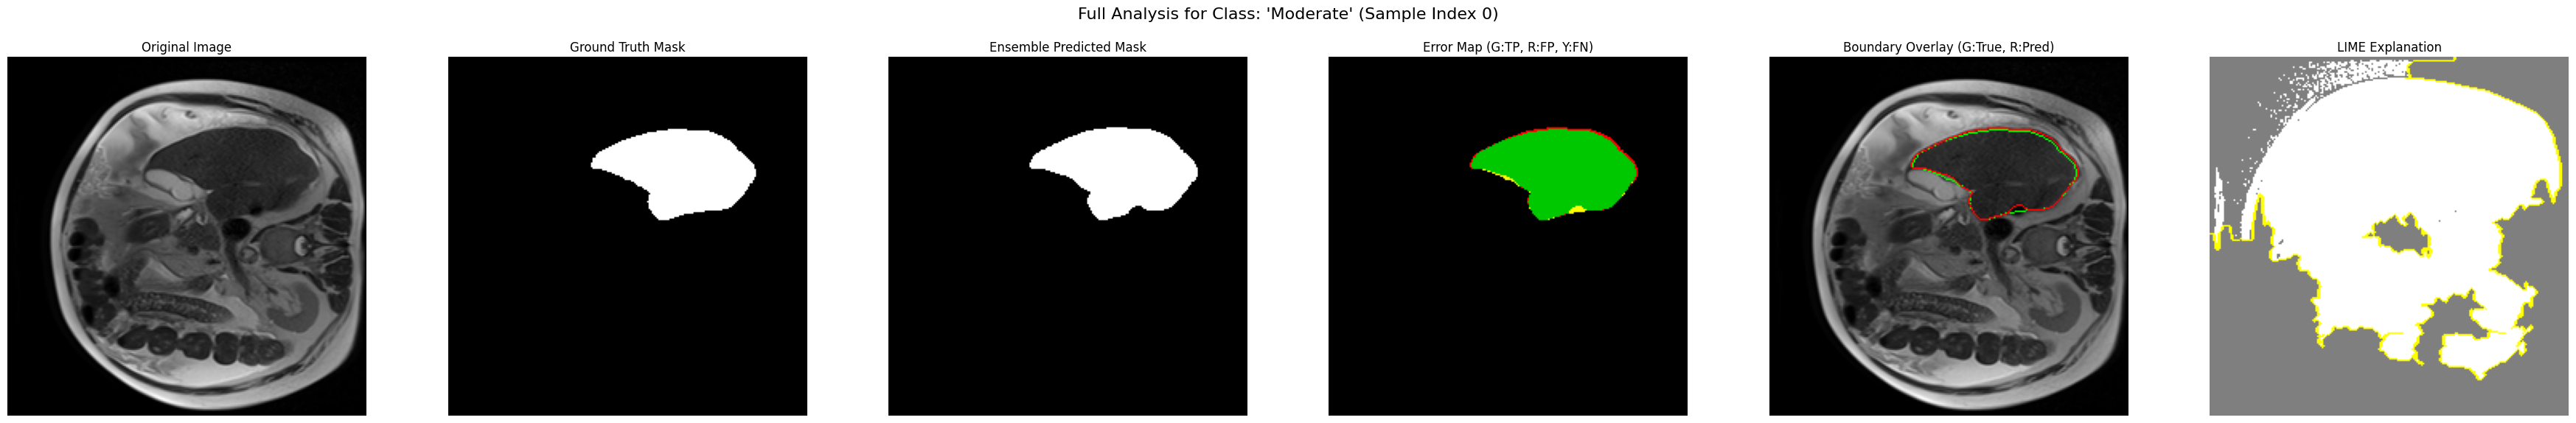


Generating Full Analysis for Class 'Mild' (Sample Index 50)...


  0%|          | 0/1000 [00:00<?, ?it/s]

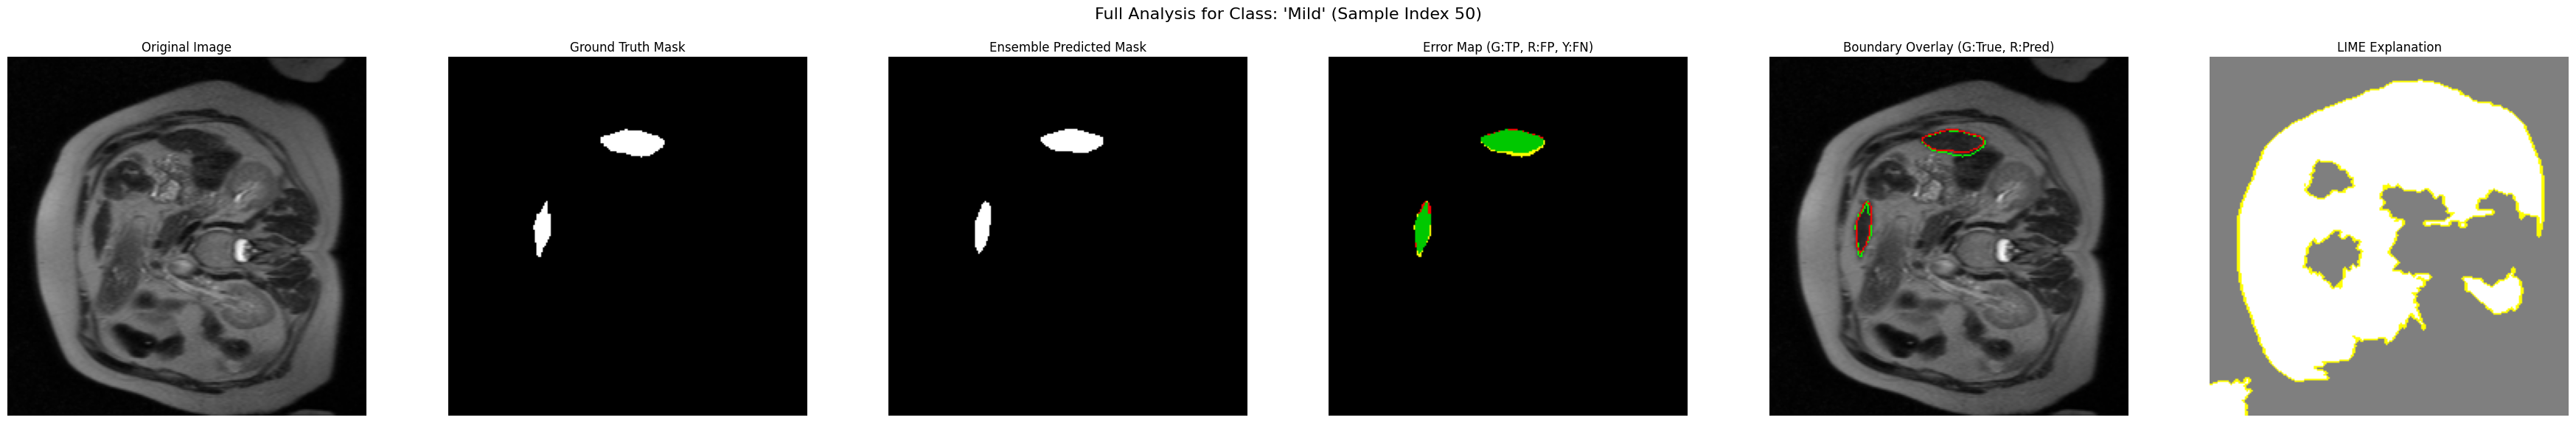


Generating Full Analysis for Class 'Severe' (Sample Index 104)...


  0%|          | 0/1000 [00:00<?, ?it/s]

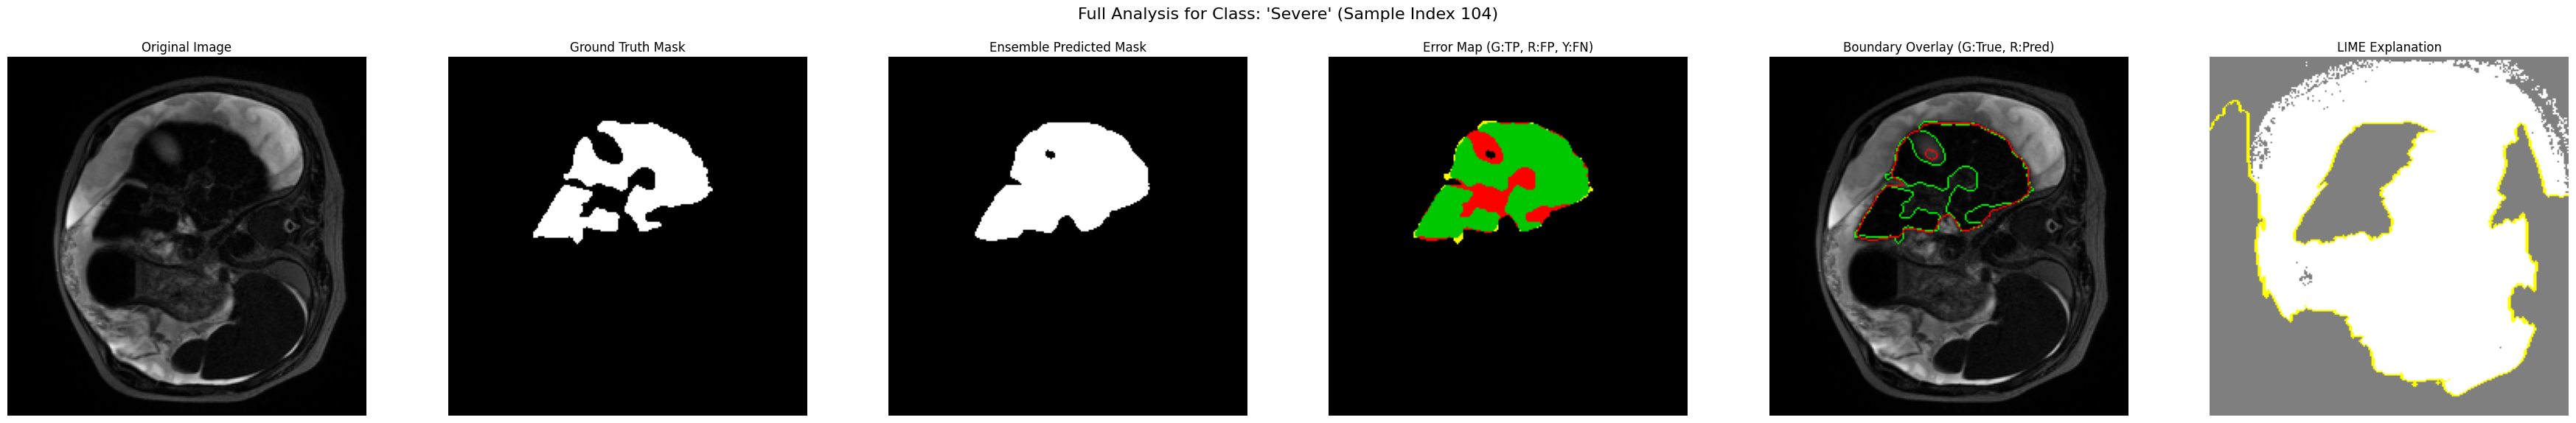



--- Starting Classification Stage ---

Preparing dataframes for classification...

An error occurred during the classification stage: 'ID'


In [5]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import mark_boundaries, find_boundaries
import torch.nn.functional as F
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from lime import lime_image
from tqdm import tqdm

# --- 1. CONFIGURATION: Your model paths ---
MODEL1_PATH = '/kaggle/input/ourensemble1/model1/best_segmentation_model1.pth'
MODEL2_PATH = '/kaggle/input/ourensemble1/model1/best_transunetpp_model.pth'
MODEL3_PATH = '/kaggle/input/model3d/best_segmentation_model3.pth'
METADATA_PATH = '/kaggle/input/t2metadata/T2_age_gender_evaluation.csv'
TEST_DIR = '/kaggle/input/datat2/Cirrhosis_T2_2D/test'

# --- 2. SETUP: Basic functions and device configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ⚙️")

# CORRECTED FUNCTION
def calculate_metrics(preds, targets, smooth=1e-6):
    preds_sig = torch.sigmoid(preds)
    preds_bin = (preds_sig > 0.5).float()
    preds_flat, targets_flat = preds_bin.view(-1), targets.view(-1) # The fix is here
    intersection = (preds_flat * targets_flat).sum()
    total = preds_flat.sum() + targets_flat.sum()
    union = total - intersection
    dice = (2. * intersection + smooth) / (total + smooth)
    iou = (intersection + smooth) / (union + smooth)
    return dice.item(), iou.item()

# --- 3. DATAFRAME CREATION AND MERGE ---
print("\n--- Creating DataFrames ---")
try:
    metadata_df = pd.read_csv(METADATA_PATH)
    metadata_df.rename(columns={'Patient ID': 'ID', 'Radiological Evaluation': 'radiological_evaluation'}, inplace=True)
    metadata_df.dropna(subset=['radiological_evaluation'], inplace=True)
    metadata_df['radiological_evaluation'] = metadata_df['radiological_evaluation'].astype(int)
    metadata_df['ID'] = metadata_df['ID'].astype(str)
    class_name_map = {1: 'Mild', 2: 'Moderate', 3: 'Severe'}
    metadata_df['class_name'] = metadata_df['radiological_evaluation'].map(class_name_map)
    metadata_df.dropna(subset=['class_name'], inplace=True)
    print("Metadata loaded and processed successfully.")
    valid_ids = set(metadata_df['ID'].tolist())

    def create_dataframe_from_ids(directory, allowed_ids):
        data = []
        if not os.path.exists(directory): return pd.DataFrame(data)
        for folder_name in os.listdir(directory):
            if folder_name in allowed_ids:
                folder_path = os.path.join(directory, folder_name)
                images_dir, masks_dir = os.path.join(folder_path, 'images'), os.path.join(folder_path, 'masks')
                if os.path.exists(images_dir) and os.path.exists(masks_dir):
                    for image_file in os.listdir(images_dir):
                        image_path = os.path.join(images_dir, image_file)
                        mask_path = os.path.join(masks_dir, image_file)
                        if os.path.exists(mask_path): data.append((folder_name, image_path, mask_path))
        return pd.DataFrame(data, columns=['ID', 'image_file_path', 'mask_file_path'])

    test_df = create_dataframe_from_ids(TEST_DIR, valid_ids)
    test_df = pd.merge(test_df, metadata_df[['ID', 'class_name']], on='ID')
    if test_df.empty: raise FileNotFoundError("Could not find any valid test images and masks.")
    print(f"Successfully created and merged test_df with {len(test_df)} samples.")
    print("Class distribution in test set:\n", test_df['class_name'].value_counts())
except Exception as e:
    print(f"Error during data setup: {e}")
    test_df = None

# --- 4. DATASET AND TRANSFORMS ---
class SegmentationTransform:
    def __init__(self, image_size=(224, 224)):
        self.image_size = image_size
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    def __call__(self, image, mask):
        image = image.resize(self.image_size, Image.BILINEAR)
        mask = mask.resize(self.image_size, Image.NEAREST)
        image_tensor = transforms.ToTensor()(image)
        mask_tensor = transforms.ToTensor()(mask)
        return self.normalize(image_tensor), (mask_tensor > 0).float()

class LiverDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_pil = Image.open(row['image_file_path']).convert('RGB')
        mask_pil = Image.open(row['mask_file_path']).convert('L')
        image, mask = self.transform(image_pil, mask_pil)
        return image, mask, row['image_file_path'], row['class_name']

# --- 5. MODEL ARCHITECTURE DEFINITIONS ---
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
    def forward(self, x, skip_connection):
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        x = torch.cat([x, skip_connection], dim=1)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

class UNetWithResNet50Encoder(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        base_model = models.resnet50(weights=None)
        base_layers = list(base_model.children())
        self.encoder0, self.encoder1 = nn.Sequential(*base_layers[:3]), nn.Sequential(*base_layers[3:5])
        self.encoder2, self.encoder3, self.encoder4 = base_layers[5], base_layers[6], base_layers[7]
        self.decoder3 = DecoderBlock(2048, 1024, 512)
        self.decoder2 = DecoderBlock(512, 512, 256)
        self.decoder1 = DecoderBlock(256, 256, 128)
        self.decoder0 = DecoderBlock(128, 64, 64)
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)
    def forward(self, x):
        e0=self.encoder0(x); e1=self.encoder1(e0); e2=self.encoder2(e1); e3=self.encoder3(e2); e4=self.encoder4(e3)
        d3=self.decoder3(e4,e3); d2=self.decoder2(d3,e2); d1=self.decoder1(d2,e1); d0=self.decoder0(d1,e0)
        out = F.interpolate(d0, scale_factor=2, mode='bilinear', align_corners=True)
        return self.final_conv(out)

class TransUNetPP(nn.Module):
    def __init__(self, n_classes=1, img_dim=224, vit_dim=768, vit_depth=12, vit_heads=12):
        super().__init__()
        base_model = models.resnet50(weights=None)
        base_layers = list(base_model.children())
        self.encoder0, self.encoder1 = nn.Sequential(*base_layers[:3]), nn.Sequential(*base_layers[3:5])
        self.encoder2, self.encoder3, self.encoder4 = base_layers[5], base_layers[6], base_layers[7]
        num_patches, self.patch_dim = (img_dim // 32) ** 2, 2048
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, vit_dim))
        self.patch_to_embedding = nn.Linear(self.patch_dim, vit_dim)
        transformer_layer = nn.TransformerEncoderLayer(d_model=vit_dim, nhead=vit_heads, dim_feedforward=vit_dim * 4, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(transformer_layer, num_layers=vit_depth)
        self.transformer_output_to_conv = nn.Sequential(nn.Linear(vit_dim, self.patch_dim), nn.LayerNorm(self.patch_dim))
        d_ch = {'d0': 64, 'd1': 128, 'd2': 256, 'd3': 512, 'd4': 1024}
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.X_0_0=ConvBlock(64,d_ch['d0']); self.X_1_0=ConvBlock(256,d_ch['d1']); self.X_0_1=ConvBlock(d_ch['d0']+d_ch['d1'],d_ch['d0'])
        self.X_2_0=ConvBlock(512,d_ch['d2']); self.X_1_1=ConvBlock(d_ch['d1']+d_ch['d2'],d_ch['d1']); self.X_0_2=ConvBlock(d_ch['d0']*2+d_ch['d1'],d_ch['d0'])
        self.X_3_0=ConvBlock(1024,d_ch['d3']); self.X_2_1=ConvBlock(d_ch['d2']+d_ch['d3'],d_ch['d2']); self.X_1_2=ConvBlock(d_ch['d1']*2+d_ch['d2'],d_ch['d1']); self.X_0_3=ConvBlock(d_ch['d0']*3+d_ch['d1'],d_ch['d0'])
        self.X_4_0=ConvBlock(2048,d_ch['d4']); self.X_3_1=ConvBlock(d_ch['d3']+d_ch['d4'],d_ch['d3']); self.X_2_2=ConvBlock(d_ch['d2']*2+d_ch['d3'],d_ch['d2']); self.X_1_3=ConvBlock(d_ch['d1']*3+d_ch['d2'],d_ch['d1']); self.X_0_4=ConvBlock(d_ch['d0']*4+d_ch['d1'],d_ch['d0'])
        self.final_conv = nn.Conv2d(d_ch['d0'], n_classes, kernel_size=1)
    def forward(self, x):
        e0=self.encoder0(x); e1=self.encoder1(e0); e2=self.encoder2(e1); e3=self.encoder3(e2); e4=self.encoder4(e3)
        bs,_,h,w = e4.shape
        trans_in = self.patch_to_embedding(e4.flatten(2).transpose(1, 2)) + self.pos_embedding
        trans_out = self.transformer_output_to_conv(self.transformer_encoder(trans_in)).transpose(1, 2).view(bs, self.patch_dim, h, w)
        x0_0=self.X_0_0(e0); x1_0=self.X_1_0(e1); x0_1=self.X_0_1(torch.cat([x0_0,self.upsample(x1_0)],1))
        x2_0=self.X_2_0(e2); x1_1=self.X_1_1(torch.cat([x1_0,self.upsample(x2_0)],1)); x0_2=self.X_0_2(torch.cat([x0_0,x0_1,self.upsample(x1_1)],1))
        x3_0=self.X_3_0(e3); x2_1=self.X_2_1(torch.cat([x2_0,self.upsample(x3_0)],1)); x1_2=self.X_1_2(torch.cat([x1_0,x1_1,self.upsample(x2_1)],1)); x0_3=self.X_0_3(torch.cat([x0_0,x0_1,x0_2,self.upsample(x1_2)],1))
        x4_0=self.X_4_0(trans_out); x3_1=self.X_3_1(torch.cat([x3_0,self.upsample(x4_0)],1)); x2_2=self.X_2_2(torch.cat([x2_0,x2_1,self.upsample(x3_1)],1)); x1_3=self.X_1_3(torch.cat([x1_0,x1_1,x1_2,self.upsample(x2_2)],1)); x0_4=self.X_0_4(torch.cat([x0_0,x0_1,x0_2,x0_3,self.upsample(x1_3)],1))
        out = F.interpolate(self.final_conv(x0_4), scale_factor=2, mode='bilinear', align_corners=True)
        return out

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        return x * self.psi(psi)

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        base = models.resnet50(weights=None)
        layers = list(base.children())
        self.encoder0, self.encoder1 = nn.Sequential(*layers[:3]), nn.Sequential(*layers[3:5])
        self.encoder2, self.encoder3, self.encoder4 = layers[5], layers[6], layers[7]
        self.upconv3 = nn.ConvTranspose2d(2048, 1024, 2, 2)
        self.attn3 = AttentionGate(1024, 1024, 512)
        self.dec_conv3 = ConvBlock(2048, 1024)
        self.upconv2 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.attn2 = AttentionGate(512, 512, 256)
        self.dec_conv2 = ConvBlock(1024, 512)
        self.upconv1 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.attn1 = AttentionGate(256, 256, 128)
        self.dec_conv1 = ConvBlock(512, 256)
        self.upconv0 = nn.ConvTranspose2d(256, 64, 2, 2)
        self.attn0 = AttentionGate(64, 64, 32)
        self.dec_conv0 = ConvBlock(128, 64)
        self.final_up = nn.ConvTranspose2d(64, 32, 2, 2)
        self.final_conv = nn.Conv2d(32, n_classes, 1)
    def forward(self, x):
        e0=self.encoder0(x); e1=self.encoder1(e0); e2=self.encoder2(e1); e3=self.encoder3(e2); e4=self.encoder4(e3)
        d3=self.upconv3(e4); x3=self.attn3(d3,e3); d3=self.dec_conv3(torch.cat((x3,d3),1))
        d2=self.upconv2(d3); x2=self.attn2(d2,e2); d2=self.dec_conv2(torch.cat((x2,d2),1))
        d1=self.upconv1(d2); x1=self.attn1(d1,e1); d1=self.dec_conv1(torch.cat((x1,d1),1))
        d0=self.upconv0(d1); x0=self.attn0(d0,e0); d0=self.dec_conv0(torch.cat((x0,d0),1))
        return self.final_conv(self.final_up(d0))

# --- 6. LOADING MODELS ---
models_loaded = False
if test_df is not None:
    try:
        print("\nLoading all three models from specified paths...")
        model1 = UNetWithResNet50Encoder(n_classes=1).to(device)
        model1.load_state_dict(torch.load(MODEL1_PATH, map_location=device))
        model1.eval()

        model2 = TransUNetPP(n_classes=1).to(device)
        model2.load_state_dict(torch.load(MODEL2_PATH, map_location=device))
        model2.eval()

        model3 = AttentionUNet(n_classes=1).to(device)
        model3.load_state_dict(torch.load(MODEL3_PATH, map_location=device))
        model3.eval()

        print("All models loaded successfully! ✅")
        models_loaded = True
    except FileNotFoundError as e:
        print(f"Error loading files: {e}\nPlease check that all model paths are correct.")
    except RuntimeError as e:
        print(f"\n--- MODEL LOADING FAILED --- ❌")
        print(f"ERROR: A model architecture does not match its saved weights file!")
        print(f"DETAILS: {e}")
        print("Please ensure the correct model class is used for each model path.")

# --- 7. PREDICTION, EVALUATION, AND VISUALIZATION ---
if models_loaded:
    test_transform = SegmentationTransform()
    test_dataset = LiverDataset(test_df, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

    all_preds1, all_preds2, all_preds3, all_gt_masks = [], [], [], []
    print("\nGenerating predictions and collecting ground truths...")
    with torch.no_grad():
        for images, masks, _, _ in tqdm(test_loader):
            images = images.to(device)
            all_preds1.append(model1(images).cpu())
            all_preds2.append(model2(images).cpu())
            all_preds3.append(model3(images).cpu())
            all_gt_masks.append(masks.cpu())

    preds1 = torch.cat(all_preds1)
    preds2 = torch.cat(all_preds2)
    preds3 = torch.cat(all_preds3)
    ground_truth_masks = torch.cat(all_gt_masks)

    print("\nEnsembling predictions...")
    ensembled_preds = torch.mean(torch.stack([preds1, preds2, preds3]), dim=0)

    print("\n--- Final Ensembled Performance ---")
    ensembled_dice, ensembled_iou = calculate_metrics(ensembled_preds, ground_truth_masks)
    print(f"Ensembled Dice Score: {ensembled_dice:.4f}")
    print(f"Ensembled mIoU Score:  {ensembled_iou:.4f}")

    print("\n--- Individual Model Performance ---")
    dice1, iou1 = calculate_metrics(preds1, ground_truth_masks); print(f"Model 1 (UNet-ResNet50) -> Dice: {dice1:.4f}, mIoU: {iou1:.4f}")
    dice2, iou2 = calculate_metrics(preds2, ground_truth_masks); print(f"Model 2 (TransUNetPP)   -> Dice: {dice2:.4f}, mIoU: {iou2:.4f}")
    dice3, iou3 = calculate_metrics(preds3, ground_truth_masks); print(f"Model 3 (AttentionUNet) -> Dice: {dice3:.4f}, mIoU: {iou3:.4f}")

    explainer = lime_image.LimeImageExplainer()
    def batch_predict_for_ensemble_lime(images_np):
        preprocess = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])
        images_torch = torch.stack([preprocess(Image.fromarray(img)) for img in images_np]).to(device).float()
        with torch.no_grad():
            logits1=model1(images_torch); logits2=model2(images_torch); logits3=model3(images_torch)
            ensembled_logits = torch.mean(torch.stack([logits1, logits2, logits3]), dim=0)
        probs = torch.sigmoid(ensembled_logits); confidence = probs.mean(dim=[1,2,3])
        return torch.stack([1 - confidence, confidence], dim=1).cpu().numpy()

    def visualize_segmentation_errors(pred_mask, true_mask, tp_color=[0, 200, 0], fp_color=[255, 0, 0], fn_color=[255, 255, 0]):
        pred_mask, true_mask = pred_mask.astype(bool), true_mask.astype(bool)
        error_image = np.zeros((*true_mask.shape, 3), dtype=np.uint8)
        error_image[pred_mask & true_mask] = tp_color
        error_image[pred_mask & ~true_mask] = fp_color
        error_image[~pred_mask & true_mask] = fn_color
        return error_image

    def visualize_boundary_overlay(image, true_mask, pred_mask, true_color=[0, 255, 0], pred_color=[255, 0, 0]):
        image_overlay = np.array(image).copy()
        true_boundaries = find_boundaries(true_mask, mode='inner').astype(np.uint8)
        pred_boundaries = find_boundaries(pred_mask, mode='inner').astype(np.uint8)
        image_overlay[true_boundaries == 1] = true_color
        image_overlay[pred_boundaries == 1] = pred_color
        return image_overlay

    def generate_full_analysis_plot(image_idx):
        class_name = test_df.iloc[image_idx]['class_name']
        print(f"\nGenerating Full Analysis for Class '{class_name}' (Sample Index {image_idx})...")
        image_path = test_df.iloc[image_idx]['image_file_path']
        original_image = Image.open(image_path).convert('RGB').resize((224, 224))
        gt_mask = ground_truth_masks[image_idx].cpu().squeeze().numpy()
        pred_mask_ensembled = (torch.sigmoid(ensembled_preds[image_idx]) > 0.5).cpu().squeeze().numpy()
        explanation = explainer.explain_instance(np.array(original_image), batch_predict_for_ensemble_lime, top_labels=2, hide_color=0, num_samples=1000, random_seed=42)
        lime_explanation_img, lime_mask = explanation.get_image_and_mask(label=1, positive_only=True, num_features=15, hide_rest=True)
        error_map = visualize_segmentation_errors(pred_mask_ensembled, gt_mask)
        boundary_map = visualize_boundary_overlay(original_image, gt_mask, pred_mask_ensembled)

        fig, axes = plt.subplots(1, 6, figsize=(36, 6))
        fig.suptitle(f"Full Analysis for Class: '{class_name}' (Sample Index {image_idx})", fontsize=16)
        axes[0].imshow(original_image); axes[0].set_title("Original Image")
        axes[1].imshow(gt_mask, cmap='gray'); axes[1].set_title("Ground Truth Mask")
        axes[2].imshow(pred_mask_ensembled, cmap='gray'); axes[2].set_title("Ensemble Predicted Mask")
        axes[3].imshow(error_map); axes[3].set_title("Error Map (G:TP, R:FP, Y:FN)")
        axes[4].imshow(boundary_map); axes[4].set_title("Boundary Overlay (G:True, R:Pred)")
        axes[5].imshow(mark_boundaries(lime_explanation_img / 2 + 0.5, lime_mask)); axes[5].set_title("LIME Explanation")
        for ax in axes: ax.axis('off')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

    print("\n--- Visualizing One Sample Per Class ---")
    samples_to_show_df = test_df.reset_index().drop_duplicates(subset=['class_name'])
    for _, row in samples_to_show_df.iterrows():
        generate_full_analysis_plot(row['index'])
else:
    print("\nSkipping model execution due to file loading or data setup errors.")
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
# =================================================================================
# --- 8. CLASSIFICATION STAGE ---
# =================================================================================

print("\n\n--- Starting Classification Stage ---")

# --- 8.1 CONFIGURATION: ট্রেইন এবং ভ্যালিডেশন ডেটার জন্য পাথ আপডেট করুন ---
# অনুগ্রহ করে এই পাথগুলো আপনার আসল training এবং validation ফোল্ডারের সাথে পরিবর্তন করুন।
TRAIN_DIR = '/kaggle/input/datat2/Cirrhosis_T2_2D/train'
VAL_DIR = '/kaggle/input/datat2/Cirrhosis_T2_2D/validation'

# radiological_evaluation (1,2,3) থেকে class_label (0,1,2) তে ম্যাপ করা
# আপনার আগের কোডে class_name ম্যাপ করা ছিল, এখানে আমরা ক্লাসের জন্য লেবেলও ম্যাপ করে নিচ্ছি।
class_label_map = {1: 0, 2: 1, 3: 2}
metadata_df['class_label'] = metadata_df['radiological_evaluation'].map(class_label_map)


if not models_loaded:
    print("Skipping classification stage because segmentation models failed to load.")
else:
    try:
        # --- 8.2 ক্লাসিফিকেশনের জন্য DATAFRAMES প্রস্তুত করা ---
        print("\nPreparing dataframes for classification...")
        
        train_df_cls = create_dataframe_from_ids(TRAIN_DIR, valid_ids)
        val_df_cls = create_dataframe_from_ids(VAL_DIR, valid_ids)
        # test_df আগের সেকশনে তৈরি করা আছে
        
        # মেটাডেটা থেকে class_label যোগ করা
        train_df_cls = pd.merge(train_df_cls, metadata_df[['ID', 'class_name', 'class_label']], on='ID')
        val_df_cls = pd.merge(val_df_cls, metadata_df[['ID', 'class_name', 'class_label']], on='ID')
        test_df = pd.merge(test_df, metadata_df[['ID', 'class_label']], on='ID', how='left') # test_df-এ class_label যোগ করা

        if train_df_cls.empty or val_df_cls.empty:
            raise FileNotFoundError("Could not find training/validation data. Please check TRAIN_DIR and VAL_DIR paths.")

        print(f"Loaded {len(train_df_cls)} training, {len(val_df_cls)} validation, and {len(test_df)} test samples for classification.")
        
        # --- 8.3 FEATURE হিসেবে SEGMENTATION PREDICTIONS তৈরি করা ---
        print("\nGenerating segmentation predictions to use as features for the classifier...")

        def get_segmentation_predictions(loader, model1, model2, model3):
            """Ensemble segmentation মডেল চালিয়ে predicted masks রিটার্ন করে।"""
            all_preds = []
            with torch.no_grad():
                for images, _, _, _ in tqdm(loader, desc="Generating Pred Masks"):
                    images = images.to(device)
                    preds1 = model1(images)
                    preds2 = model2(images)
                    preds3 = model3(images)
                    ensembled = torch.sigmoid(torch.mean(torch.stack([preds1, preds2, preds3]), dim=0))
                    all_preds.append((ensembled > 0.5).float().cpu())
            return torch.cat(all_preds)

        # predictions পাওয়ার জন্য DataLoader তৈরি করা
        train_seg_dataset = LiverDataset(train_df_cls, transform=test_transform)
        val_seg_dataset = LiverDataset(val_df_cls, transform=test_transform)
        test_seg_dataset = LiverDataset(test_df, transform=test_transform)

        train_seg_loader = DataLoader(train_seg_dataset, batch_size=16, shuffle=False)
        val_seg_loader = DataLoader(val_seg_dataset, batch_size=16, shuffle=False)
        test_seg_loader = DataLoader(test_seg_dataset, batch_size=16, shuffle=False)

        # প্রতিটি ডেটাসেটের জন্য predicted masks তৈরি করা
        train_pred_masks = get_segmentation_predictions(train_seg_loader, model1, model2, model3)
        val_pred_masks = get_segmentation_predictions(val_seg_loader, model1, model2, model3)
        test_pred_masks = (torch.sigmoid(ensembled_preds) > 0.5).float() # আগের সেকশন থেকে পুনরায় ব্যবহার করা

        print("Segmentation predictions generated successfully.")

        # --- 8.4 CLASSIFICATION DATASET ---
        class ClassificationDataset(Dataset):
            def __init__(self, dataframe, predicted_masks, transform):
                self.dataframe = dataframe
                self.predicted_masks = predicted_masks
                self.transform = transform

            def __len__(self):
                return len(self.dataframe)

            def __getitem__(self, idx):
                row = self.dataframe.iloc[idx]
                image_pil = Image.open(row['image_file_path']).convert('RGB')
                mask_pil = Image.open(row['mask_file_path']).convert('L')
                
                image, gt_mask = self.transform(image_pil, mask_pil)
                pred_mask = self.predicted_masks[idx]

                # ছবি (3 channels), আসল মাস্ক (1 channel), এবং predicted মাস্ক (1 channel) একসাথে যুক্ত করা
                # এটি আমাদের ক্লাসিফায়ারের জন্য একটি 5-channel ইনপুট তৈরি করে
                combined_input = torch.cat([image, gt_mask, pred_mask], dim=0)
                
                label = torch.tensor(row['class_label'], dtype=torch.long)
                
                return combined_input, label

        cls_transform = SegmentationTransform()
        train_cls_dataset = ClassificationDataset(train_df_cls, train_pred_masks, cls_transform)
        val_cls_dataset = ClassificationDataset(val_df_cls, val_pred_masks, cls_transform)
        test_cls_dataset = ClassificationDataset(test_df, test_pred_masks, cls_transform)

        train_cls_loader = DataLoader(train_cls_dataset, batch_size=16, shuffle=True)
        val_cls_loader = DataLoader(val_cls_dataset, batch_size=16, shuffle=False)
        test_cls_loader = DataLoader(test_cls_dataset, batch_size=16, shuffle=False)
        
        print("\nClassification datasets and loaders are ready.")

        # --- 8.5 CLASSIFICATION MODEL ARCHITECTURE ---
        class CirrhosisClassifier(nn.Module):
            def __init__(self, n_classes=3, in_channels=5):
                super().__init__()
                self.base_model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
                
                original_conv1 = self.base_model.conv1
                self.base_model.conv1 = nn.Conv2d(
                    in_channels, 
                    original_conv1.out_channels, 
                    kernel_size=original_conv1.kernel_size, 
                    stride=original_conv1.stride, 
                    padding=original_conv1.padding, 
                    bias=False
                )
                
                num_ftrs = self.base_model.fc.in_features
                self.base_model.fc = nn.Linear(num_ftrs, n_classes)

            def forward(self, x):
                return self.base_model(x)
        
        # --- 8.6 TRAINING AND EVALUATION ---
        cls_model = CirrhosisClassifier(n_classes=3).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(cls_model.parameters(), lr=1e-4)
        num_epochs = 25

        print("\n--- Starting Classifier Training ---")
        best_val_accuracy = 0.0
        
        for epoch in range(num_epochs):
            cls_model.train()
            running_loss = 0.0
            for inputs, labels in tqdm(train_cls_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = cls_model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            # Validation phase
            cls_model.eval()
            val_corrects = 0
            with torch.no_grad():
                for inputs, labels in val_cls_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = cls_model(inputs)
                    _, preds = torch.max(outputs, 1)
                    val_corrects += torch.sum(preds == labels.data)
            
            val_accuracy = val_corrects.double() / len(val_cls_dataset)
            print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_cls_loader):.4f} | Val Accuracy: {val_accuracy:.4f}")
            
            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                torch.save(cls_model.state_dict(), 'best_classifier_model.pth')
                print(f"   -> ✅ New best model saved with accuracy: {best_val_accuracy:.4f}")

        print("\n--- Training Finished ---")

        # --- 8.7 FINAL EVALUATION ON TEST SET ---
        print("\n--- Evaluating on Test Set ---")
        cls_model.load_state_dict(torch.load('best_classifier_model.pth'))
        cls_model.eval()
        
        all_labels, all_preds = [], []
        
        with torch.no_grad():
            for inputs, labels in tqdm(test_cls_loader, desc="Testing"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = cls_model(inputs)
                _, preds = torch.max(outputs, 1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                
        # --- 8.8 DISPLAY METRICS ---
        class_names = ['Mild', 'Moderate', 'Severe']
        print("\n--- Classification Report ---")
        print(classification_report(all_labels, all_preds, target_names=class_names))
        
        print("\n--- Confusion Matrix ---")
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        
        fig, ax = plt.subplots(figsize=(8, 8))
        disp.plot(ax=ax, cmap=plt.cm.Blues)
        plt.title("Confusion Matrix")
        plt.show()

    except Exception as e:
        print(f"\nAn error occurred during the classification stage: {e}")